# Figure 1 Jupyter Notebook

This file produces the simulation inset for Figure 1.

## Imports

In [1]:
import meshio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib as mpl

## Read Data and Plot

In [2]:
DATA_FILE = '/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab members/ZhongLab_Alex/Simulations/sic_simulation_field.vtu'

mesh = meshio.read(DATA_FILE)

for i, name in enumerate(mesh.point_data.keys()):
    print(f'{i}: {name}')

0: Electric_field_norm_@_2.1495-0.033283i_1
1: Electric_field_norm_@_2.1539-0.02417i_1
2: Electric_field_norm_@_2.1585-0.011974i_1
3: Electric_field_norm_@_2.1613_1
4: Electric_field_norm_@_2.165+0.0017501i_1
5: Electric_field_norm_@_2.1708+0.013035i_1
6: Electric_field_norm_@_2.1747+0.022368i_1
7: Electric_field_norm_@_2.1787+0.034774i_1
8: Electric_field_norm_@_2.1844+0.051062i_1
9: Electric_field_norm_@_2.1902+0.064135i_1


In [3]:
data_index = 3

triangles = mesh.cells[0].data
points = mesh.points
x = points[:,0] / 1e3  # convert to um
y = points[:,1] / 1e3  # convert to um

data_name = list(mesh.point_data.keys())[data_index]
data = mesh.point_data[data_name]

# Main Plot Code

First, we define plot parameters

In [4]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 8})
figsize = (2, 1.5)  # inches
dpi = 100
include_subplot_titles = False

# colors
cmap = 'viridis'
annotation_color = 'white'  # color of text and waveguide geometry

vertical_padding = 0.02
horizontal_padding = 0.02

We define the parameters for the waveguide shape here

In [5]:
wg_width = 2.5  # unit: um
wg_height = 0.3
hsq_height = 0.05

Text(0, 0.5, 'Z ($\\mathrm{\\mu}$m)')

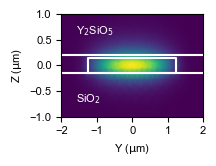

In [6]:
fig, ax = plt.subplots(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)

triangulation = tri.Triangulation(x, y, triangles)
ax.tripcolor(triangulation, data, shading='gouraud', cmap=cmap)

# make waveguide box
ax.plot((-wg_width/2, wg_width/2, wg_width/2, -wg_width/2, -wg_width/2),
         (-wg_height/2, -wg_height/2, wg_height/2, wg_height/2, -wg_height/2), color=annotation_color)
# make HSQ top and bottom
ax.axhline(y=(hsq_height+wg_height/2), color=annotation_color)
ax.axhline(y=-wg_height/2, color=annotation_color)
# make labels
ax.text(0.1, 0.9, r'Y$_2$SiO$_5$',
        ha='left', va='top', transform=ax.transAxes, color=annotation_color)
ax.text(0.1, 0.1, r'SiO$_2$',
        ha='left', va='bottom', transform=ax.transAxes, color=annotation_color)

ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)
ax.set_xlabel(r'Y ($\mathrm{\mu}$m)')
ax.set_ylabel(r'Z ($\mathrm{\mu}$m)')

In [7]:
fig.savefig('fig1_sim_short.pdf', transparent=True)

## Short Figure

In [15]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figsize = (2, 1.25)  # inches
dpi = 300
include_subplot_titles = False

# colors
cmap = 'Reds'
annotation_color = 'black'  # color of text and waveguide geometry
annotation_width = 0.5

vertical_padding = 0.02
horizontal_padding = 0.02

Text(0, 0.5, 'Z ($\\mathrm{\\mu}$m)')

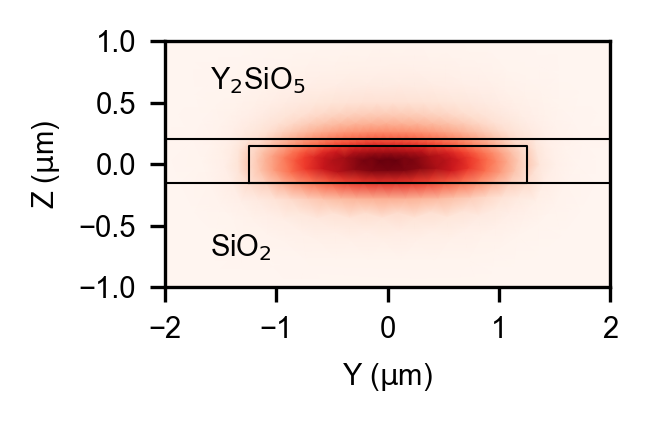

In [16]:
fig, ax = plt.subplots(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)

triangulation = tri.Triangulation(x, y, triangles)
ax.tripcolor(triangulation, data, shading='gouraud', cmap=cmap)

# make waveguide box
ax.plot((-wg_width/2, wg_width/2, wg_width/2, -wg_width/2, -wg_width/2),
         (-wg_height/2, -wg_height/2, wg_height/2, wg_height/2, -wg_height/2),
        color=annotation_color, linewidth=annotation_width)
# make HSQ top and bottom
ax.axhline(y=(hsq_height+wg_height/2), color=annotation_color, linewidth=annotation_width)
ax.axhline(y=-wg_height/2, color=annotation_color, linewidth=annotation_width)
# make labels
ax.text(0.1, 0.9, r'Y$_2$SiO$_5$',
        ha='left', va='top', transform=ax.transAxes, color=annotation_color)
ax.text(0.1, 0.1, r'SiO$_2$',
        ha='left', va='bottom', transform=ax.transAxes, color=annotation_color)

ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)
ax.set_xlabel(r'Y ($\mathrm{\mu}$m)')
ax.set_ylabel(r'Z ($\mathrm{\mu}$m)')

In [10]:
fig.savefig('fig1_sim_short.pdf')